<h1 style="text-align: center;"><strong>Customer Segmentation Using Clustering (K-Means)</strong></h1>


## **Introduction**

In today’s competitive market, businesses need to understand their customers' purchasing behaviors to enhance marketing strategies and customer satisfaction. This project focuses on **Customer Segmentation** using the **K-Means Clustering** algorithm, which helps group customers based on their spending patterns and annual income.

By analyzing the **Mall Customers dataset**, we can identify distinct clusters of shoppers, enabling businesses to tailor their offerings to different customer groups. This project walks through the process of data cleaning, exploratory data analysis, determining the optimal number of clusters using the **Elbow Method**, and applying the **K-Means Clustering** algorithm. The results are visualized to provide clear insights into different customer segments.

This project not only demonstrates technical proficiency in data analysis and machine learning but also highlights how clustering can be leveraged to drive **business decisions** such as personalized marketing, targeted promotions, and improved customer retention.

### **What is K-Means Clustering?**  

K-Means is an **unsupervised machine learning algorithm** used for **clustering** data into distinct groups. It is widely used in **customer segmentation, pattern recognition, and anomaly detection**.  

#### **How K-Means Works**
1. **Choose the number of clusters (K):**  
   - The user specifies how many clusters they want the data to be divided into.
  
2. **Initialize Cluster Centroids:**  
   - K random points (centroids) are selected as the initial centers of the clusters.

3. **Assign Data Points to Clusters:**  
   - Each data point is assigned to the nearest centroid, forming K groups.

4. **Update Centroids:**  
   - The centroid of each cluster is recalculated as the average of all points in that cluster.

5. **Repeat Until Convergence:**  
   - Steps 3 and 4 are repeated until the centroids no longer change significantly.

#### **How to Determine the Optimal K?**
- The **Elbow Method** is commonly used to find the ideal number of clusters.  
- It plots the **Within-Cluster Sum of Squares (WCSS)** against the number of clusters.  
- The point where the WCSS curve bends (the "elbow") suggests the best K value.

#### **Applications of K-Means**
- **Customer Segmentation** (grouping customers based on spending behavior)  
- **Market Basket Analysis** (identifying similar purchasing habits)  
- **Image Compression** (reducing colors in an image)  
- **Anomaly Detection** (detecting fraudulent transactions)  

_______________________________________________________________________________________________________________________________________________

### **Data collection and analysis**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# Data collection and analysis
data = pd.read_csv("Mall_Customers.csv")
data

data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### **About the dataset**

In [5]:
# finding no of rows and colums and some information of the dataset
data.shape
print(data.info())

# checking for any null values
print(data.isnull().sum())

print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.00000

### **What is WCSS (Within-Cluster Sum of Squares)?**  

WCSS (Within-Cluster Sum of Squares) is a metric used in **K-Means clustering** to measure the compactness of clusters. It calculates the sum of the squared distances between each data point and its assigned cluster centroid.  

#### **Formula for WCSS:**
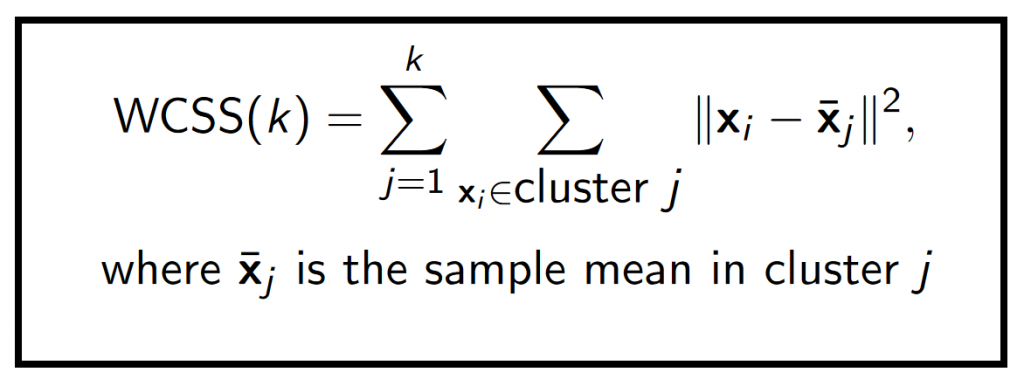 

#### **How WCSS is Used?**
- **Lower WCSS** indicates that the points in each cluster are closer to the centroid, meaning **better clustering**.  
- The **Elbow Method** is used to find the optimal number of clusters by plotting WCSS vs. number of clusters. The "elbow point" in the graph suggests the best value for \( K \), where adding more clusters doesn't significantly reduce WCSS.


In [10]:
# selecting the columns annual income and spending score
X = data.iloc[:,[3,4]].values
print(X[2:10])

# finding the wcss values for different number of clusters - wcss should be minimum
wcss = []

for i in range(1,11): # upto 11 clusters
    kmeans = KMeans(n_clusters=i, init="k-means++", random_state=42)
    kmeans.fit(X)

    # https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html
    wcss.append(kmeans.inertia_)

[[16  6]
 [16 77]
 [17 40]
 [17 76]
 [18  6]
 [18 94]
 [19  3]
 [19 72]]


### **Elbow Plot & Elbow Point**  

The **Elbow Plot** is a graph used in **K-Means clustering** to determine the **optimal number of clusters (K)**. It plots the **WCSS (Within-Cluster Sum of Squares)** against different values of K.  

#### **Elbow Point:**  
- The point where the **WCSS stops decreasing significantly** and forms a "bend" or "elbow" in the curve.  
- This is the **optimal number of clusters** because adding more clusters beyond this point doesn't improve clustering much.  

#### **Why is it Important?**  
- Too few clusters → Data points are not well separated.  
- Too many clusters → Overfitting, unnecessary complexity.  
- The **Elbow Point** balances efficiency and accuracy in clustering.

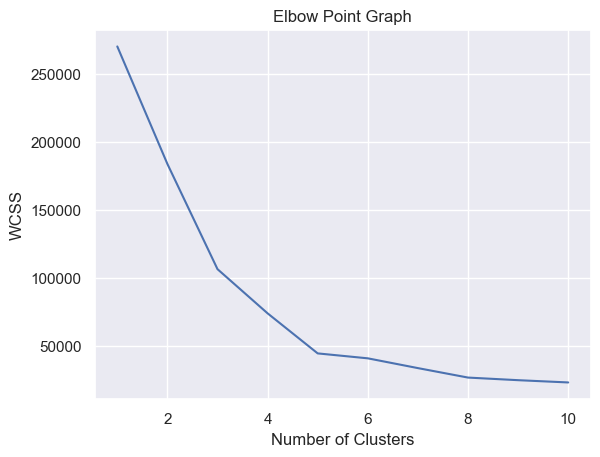

In [7]:
# making an elbow plot to check the cluster that gives minimum value

sns.set()
plt.plot(range(1,11), wcss)
plt.title("Elbow Point Graph")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

### **Inferences from the Plot**  

1. **Elbow Point Identification:**  
   - The "bend" in the graph appears at **K = 5**, meaning **5 clusters** is the optimal choice.  
   - Before K = 5, WCSS decreases rapidly, showing that adding clusters improves the grouping.  
   - After K = 5, the decrease slows down, meaning adding more clusters **does not significantly improve the clustering**.  

2. **Conclusion:**  
   - Choosing **K = 5** balances efficiency and accuracy.  
   - More clusters beyond this point lead to **diminishing returns** in reducing WCSS.  
   - This suggests that the dataset naturally forms **5 meaningful groups** based on the selected features (Annual Income & Spending Score). 🚀

[3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3 4 3
 4 3 4 3 4 3 0 3 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 2 1 0 1 2 1 2 1 0 1 2 1 2 1 2 1 2 1 0 1 2 1 2 1
 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1]


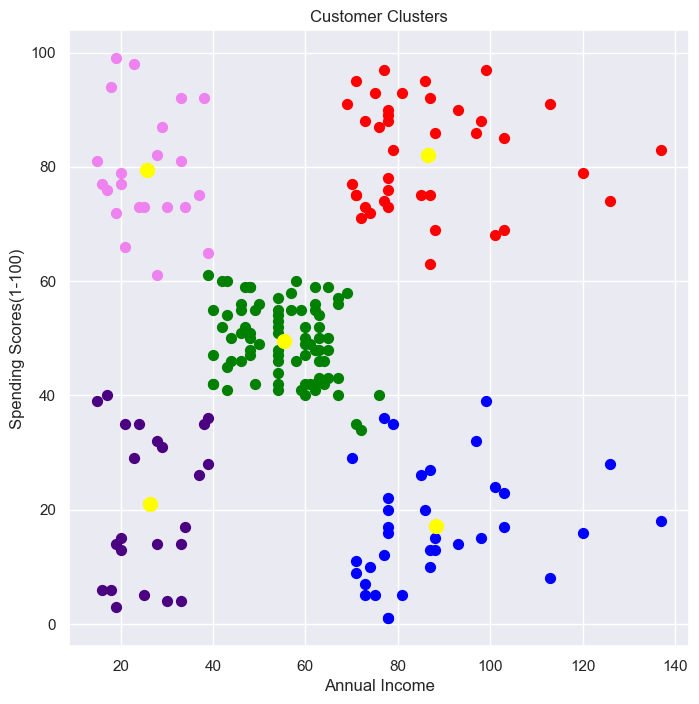

In [8]:
# Training the k means clustering model with k = 5
kmeans = KMeans(n_clusters=5, init="k-means++", random_state = 0)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X) # names the cluster
print(Y)

# visualizing all the clusters
# plotting clusters with their centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c = "green", label="Cluster 1")
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c = "red", label="Cluster 2")
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c = "blue", label="Cluster 3")
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c = "indigo", label="Cluster 4")
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c = "violet", label="Cluster 5")

# plot all the centroids
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c="yellow", label="Centroids")

plt.title("Customer Clusters")
plt.xlabel("Annual Income")
plt.ylabel("Spending Scores(1-100)")

plt.show()


### **Inference from the Cluster Plot**  

This plot represents customer segmentation using the **K-Means clustering algorithm** with **5 clusters**, identified by different colors. The x-axis represents **Annual Income**, and the y-axis represents **Spending Score (1-100)**.

#### **Observations:**
1. **Five Distinct Customer Segments**  
   - Each color represents a different cluster, meaning customers with similar spending habits and income levels are grouped together.
   
2. **Cluster Interpretation:**  
   - **Purple Cluster (Low Income, Low Spending Score)** → Budget-conscious customers with minimal spending.  
   - **Pink Cluster (Low Income, High Spending Score)** → Customers with limited income but high spending, possibly impulsive buyers.  
   - **Green Cluster (Mid Income, Mid Spending Score)** → Average consumers with balanced spending habits.  
   - **Blue Cluster (High Income, Low Spending Score)** → Wealthy but frugal customers.  
   - **Red Cluster (High Income, High Spending Score)** → High-income customers who also spend a lot, likely premium shoppers.  

3. **Yellow Dots (Cluster Centers)**  
   - Represent the centroids of each cluster, indicating the central tendency of each group.  


# **Conclusion**

The K-Means clustering algorithm successfully segments customers into **five distinct groups** based on their **Annual Income and Spending Score**. These clusters help identify different types of consumers, such as budget-conscious shoppers, premium spenders, and average buyers. The visual representation makes it easier to **analyze customer behavior** and tailor business strategies accordingly.

---

### **Business Insights**  

1. **Personalized Marketing & Targeted Promotions**  
   - High-spending customers (Red Cluster) → **Exclusive offers & premium services**.  
   - Low-spending customers with high income (Blue Cluster) → **Encourage spending through loyalty programs**.  
   - Low-income but high-spending customers (Pink Cluster) → **Introduce budget-friendly product recommendations**.  


2. **Optimized Pricing Strategy**  
   - Businesses can **adjust pricing** and **offer discounts** based on customer categories, maximizing revenue while maintaining affordability for different groups.  

3. **Inventory & Product Strategy**  
   - Knowing customer segments allows businesses to **stock relevant products**, ensuring that high-end items are available for premium customers while offering affordable options for budget-conscious buyers.  

---